# IBM HR Employee Attrition — EDA & Data Preprocessing


- Analyze 1,470 employee records and 35 HR features.
- Perform data cleaning and preprocessing.
- Use univariate, bivariate, and correlation analysis to investigate attrition.
- Examine relationships involving job level, monthly income, experience/tenure, job role, and department.
- Identify groups with comparatively high attrition counts and attrition rates.


In [1]:
## 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [ ]:
## 2. Load Data & Initial Inspection
df = pd.read_csv("HR_Analytics.csv", encoding="unicode_escape")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1480, 38)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,1,405,3,Male,54,3,1,Laboratory Technician,3,Single,1420,Upto 5k,25233,1,Y,No,13,3,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,1,411,4,Female,69,2,1,Sales Representative,3,Single,1200,Upto 5k,9724,1,Y,No,12,3,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,1,614,2,Male,69,3,1,Sales Representative,2,Single,1878,Upto 5k,8059,1,Y,Yes,14,3,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,1,1012,2,Male,73,3,1,Research Scientist,4,Single,1051,Upto 5k,13493,1,Y,No,15,3,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,1,1156,3,Male,80,3,1,Laboratory Technician,3,Single,1904,Upto 5k,13556,1,Y,No,12,3,4,80,0,0,0,3,0,0,0,0.0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.to_frame("dtype")) #display() renders a clean, interactive HTML table and to_frame() converts the Series to a DataFrame with a column name.


Rows: 1480
Columns: 38

Data types:


,dtype
EmpID,object
Age,int64
AgeGroup,object
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object


In [ ]:
## 3. Data Quality Checks

'''Check for:
1. Missing values
2. Duplicate rows
3. Constant columns
5. Unexpected data types '''

quality = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Unique": df.nunique(),
    "Dtype": df.dtypes.astype(str)
}).sort_values("Missing", ascending=False)

display(quality)

print("Total duplicate rows:", df.duplicated().sum())

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)


,Missing,Unique,Dtype
YearsWithCurrManager,57,18,float64
RelationshipSatisfaction,0,4,int64
SalarySlab,0,4,object
MonthlyRate,0,1427,int64
NumCompaniesWorked,0,10,int64
Over18,0,1,object
OverTime,0,2,object
PercentSalaryHike,0,15,int64
PerformanceRating,0,2,int64
StandardHours,0,1,int64


Total duplicate rows: 7
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [ ]:
## 4. Data Cleaning & Preprocessing

# 1) Remove exact duplicate rows.
df = df.drop_duplicates().copy()

# 2) Standardize the target values and categorical text.
# Converts every value in Attrition from object to a string and trims whitespace.
df["Attrition"] = df["Attrition"].astype(str).str.strip()

# This loops through every categorical column and removes leading/trailing spaces.
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# 3) The following columns are constants in the IBM HR dataset and
#    contain no analytical information.
constant_to_drop = [c for c in ["EmployeeCount", "Over18", "StandardHours"] if c in df.columns]
df = df.drop(columns=constant_to_drop)

# 4) EmployeeNumber is an identifier, so it should not be treated as
#    a meaningful business predictor in EDA/correlation analysis.
#    Keep it in the cleaned dataset for traceability, but exclude it
#    from analytical feature sets.

# 5) Encode the binary target for numerical correlation analysis.
df["AttritionFlag"] = df["Attrition"].map({"No": 0, "Yes": 1})

print("Shape after cleaning:", df.shape)
print("Dropped constant columns:", constant_to_drop)
print("Missing values after cleaning:", int(df.isna().sum().sum()))
display(df.head())


Shape after cleaning: (1473, 36)
Dropped constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Missing values after cleaning: 57


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,SalarySlab,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,405,3,Male,54,3,1,Laboratory Technician,3,Single,1420,Upto 5k,25233,1,No,13,3,3,0,0,2,3,0,0,0,0.0,1
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,411,4,Female,69,2,1,Sales Representative,3,Single,1200,Upto 5k,9724,1,No,12,3,1,0,0,2,3,0,0,0,0.0,0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,614,2,Male,69,3,1,Sales Representative,2,Single,1878,Upto 5k,8059,1,Yes,14,3,4,0,0,3,3,0,0,0,0.0,1
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,1012,2,Male,73,3,1,Research Scientist,4,Single,1051,Upto 5k,13493,1,No,15,3,4,0,0,2,3,0,0,0,0.0,0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,1156,3,Male,80,3,1,Laboratory Technician,3,Single,1904,Upto 5k,13556,1,No,12,3,4,0,0,0,3,0,0,0,0.0,1


,Count,Percentage
Attrition,,
No,1236,83.91
Yes,237,16.09


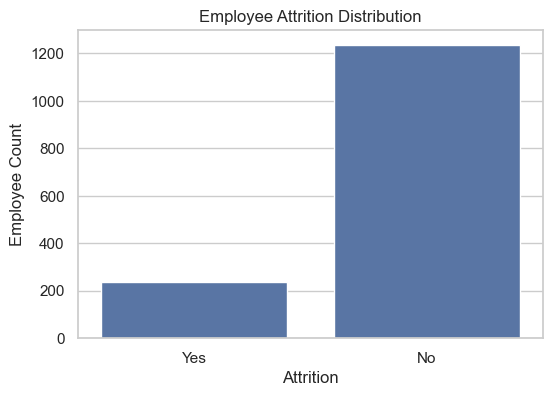

In [12]:
## 5. Target Overview — Attrition

attrition_counts = df["Attrition"].value_counts()
attrition_pct = df["Attrition"].value_counts(normalize=True).mul(100).round(2)

attrition_summary = pd.DataFrame({
    "Count": attrition_counts,
    "Percentage": attrition_pct
})

display(attrition_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.show()


### Interpretation

This establishes the baseline attrition level before investigating individual factors. The dataset contains **237 attrition cases**, corresponding to approximately **16.09%** of the 1,470 employees.


## 6. Univariate Analysis — Key Numeric Features

In [13]:
key_numeric = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion"
]

display(df[key_numeric].describe().T.round(2))


,count,mean,std,min,25%,50%,75%,max
Age,1473.0,36.92,9.13,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1473.0,6500.23,4706.05,1009.0,2911.0,4908.0,8380.0,19999.0
JobLevel,1473.0,2.06,1.11,1.0,1.0,2.0,3.0,5.0
TotalWorkingYears,1473.0,11.28,7.78,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1473.0,7.00,6.12,0.0,3.0,5.0,9.0,40.0
YearsInCurrentRole,1473.0,4.23,3.62,0.0,2.0,3.0,7.0,18.0
YearsSinceLastPromotion,1473.0,2.18,3.22,0.0,0.0,1.0,3.0,15.0


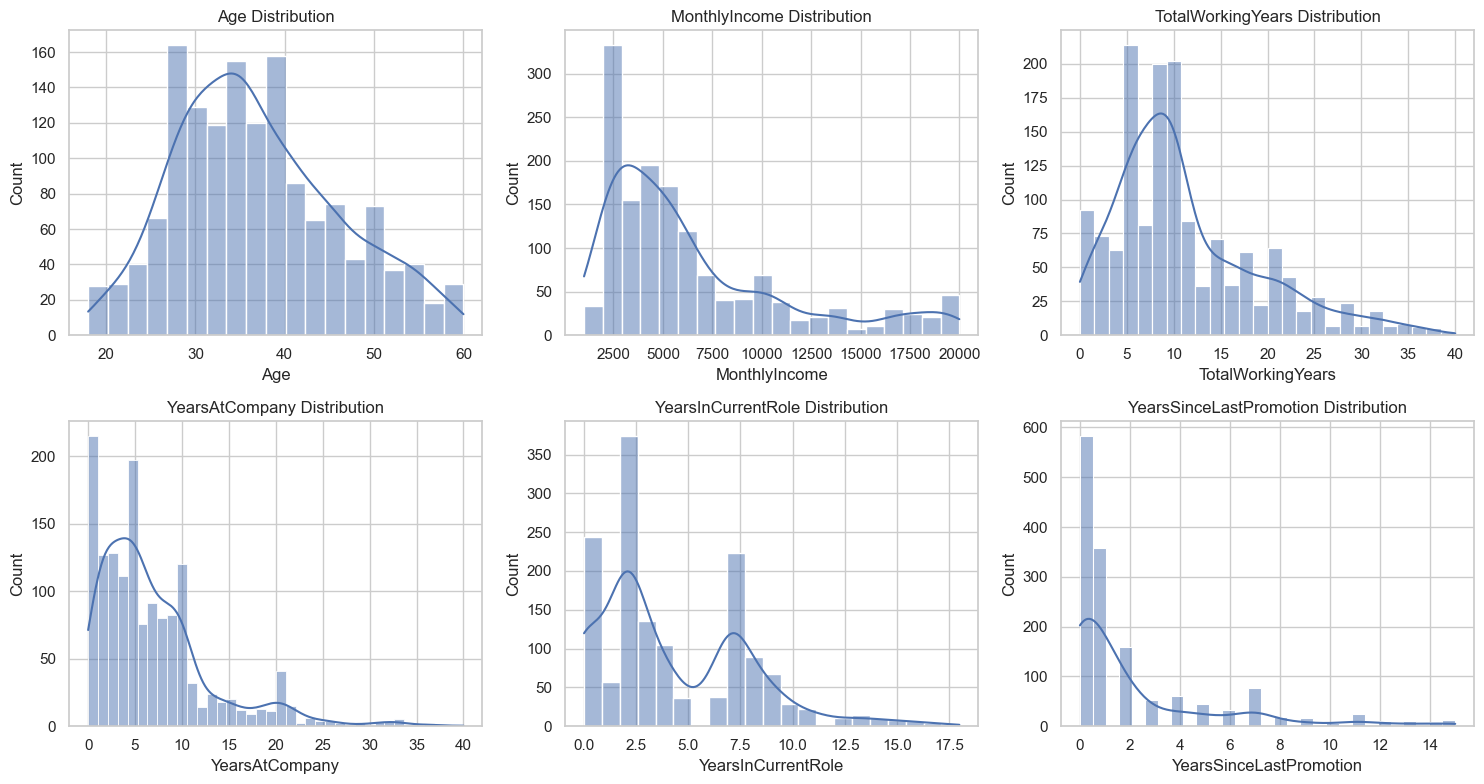

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_cols = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion"
]

for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()


**Purpose:** Univariate analysis helps understand the distribution, spread, and typical values of important employee characteristics before comparing them with attrition.


## 7. Univariate Analysis — Important Categorical Features

In [16]:
categorical_to_review = ["Department", "JobRole", "EducationField", "Gender", "OverTime"]

for col in categorical_to_review:
    print(f"\n{col}")
    display(df[col].value_counts().to_frame("Employee Count"))



Department


,Employee Count
Department,
Research & Development,963
Sales,447
Human Resources,63



JobRole


,Employee Count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,260
Manufacturing Director,145
Healthcare Representative,132
Manager,102
Sales Representative,84
Research Director,80
Human Resources,52



EducationField


,Employee Count
EducationField,
Life Sciences,606
Medical,466
Marketing,159
Technical Degree,132
Other,83
Human Resources,27



Gender


,Employee Count
Gender,
Male,884
Female,589



OverTime


,Employee Count
OverTime,
No,1057
Yes,416


## 8. Bivariate Analysis — Attrition vs. Income, Age & Experience

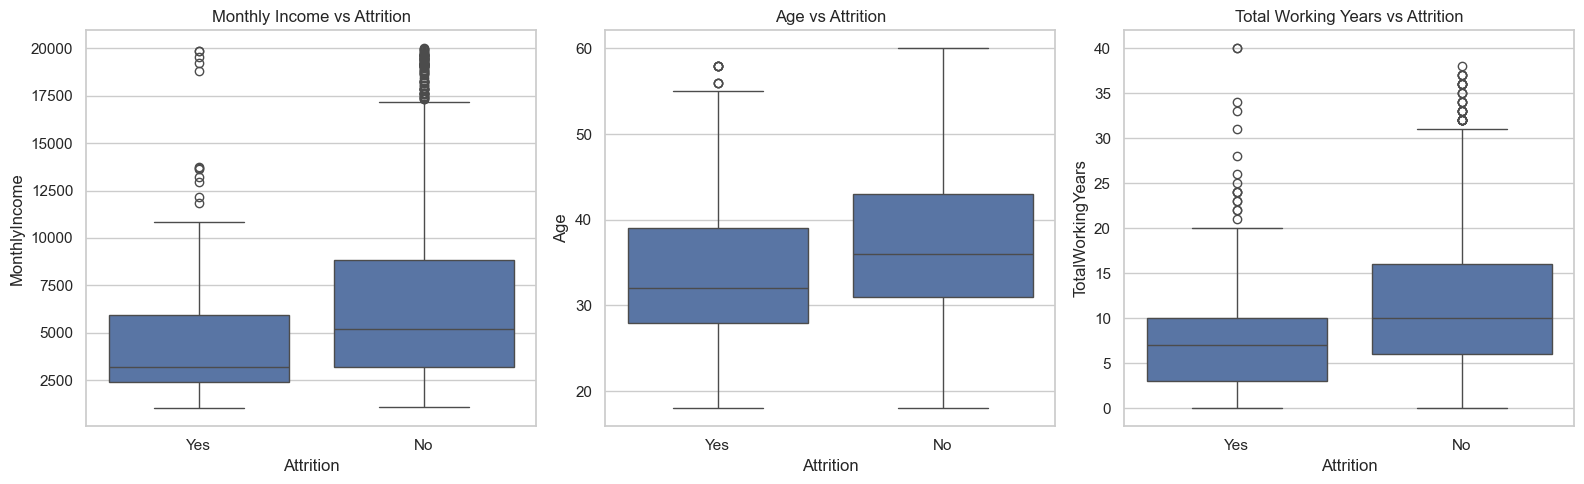

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", ax=axes[0])
axes[0].set_title("Monthly Income vs Attrition")

sns.boxplot(data=df, x="Attrition", y="Age", ax=axes[1])
axes[1].set_title("Age vs Attrition")

sns.boxplot(data=df, x="Attrition", y="TotalWorkingYears", ax=axes[2])
axes[2].set_title("Total Working Years vs Attrition")

plt.tight_layout()
plt.show()


In [18]:
# Direct group comparison for interview-ready evidence.
numeric_comparison = (
    df.groupby("Attrition")[["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany"]]
      .mean()
      .round(2)
)

display(numeric_comparison)


,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany
Attrition,,,,
No,37.55,6828.72,11.86,7.36
Yes,33.61,4787.09,8.24,5.13


## 9. Bivariate Analysis — Attrition by Job Level

,Employees,Attritions,AttritionRate_%
JobLevel,,,
1,544,143,26.29
2,535,52,9.72
3,219,32,14.61
4,106,5,4.72
5,69,5,7.25


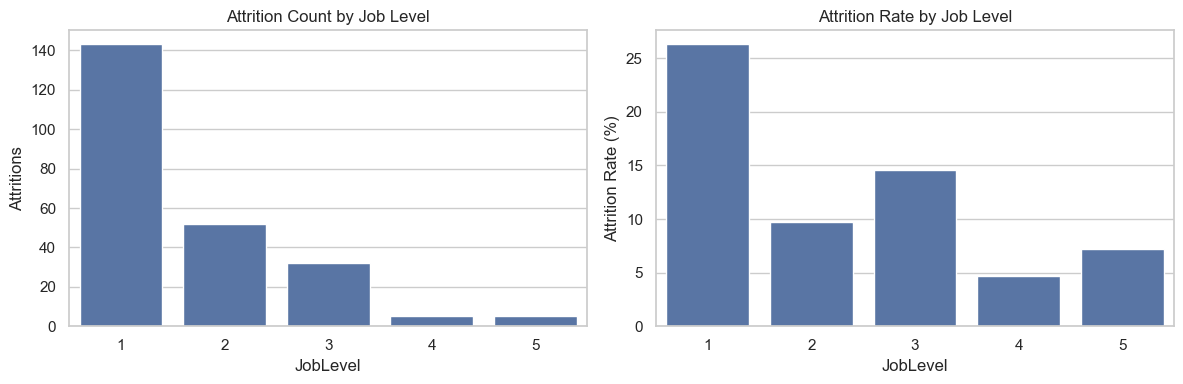

In [19]:
job_level_attrition = (
    df.groupby("JobLevel")
      .agg(
          Employees=("AttritionFlag", "size"),
          Attritions=("AttritionFlag", "sum")
      )
)

job_level_attrition["AttritionRate_%"] = (
    job_level_attrition["Attritions"] / job_level_attrition["Employees"] * 100
).round(2)

display(job_level_attrition)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=job_level_attrition.reset_index(),
    x="JobLevel", y="Attritions", ax=axes[0]
)
axes[0].set_title("Attrition Count by Job Level")

sns.barplot(
    data=job_level_attrition.reset_index(),
    x="JobLevel", y="AttritionRate_%", ax=axes[1]
)
axes[1].set_title("Attrition Rate by Job Level")
axes[1].set_ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()


## 10. Bivariate Analysis — Attrition by Job Role & Department

In [22]:
def attrition_summary_by(group_col):
    result = (
        df.groupby(group_col)
          .agg(
              Employees=("AttritionFlag", "size"),
              Attritions=("AttritionFlag", "sum")
          )
    )
    result["AttritionRate_%"] = (
        result["Attritions"] / result["Employees"] * 100
    ).round(2)
    return result.sort_values("Attritions", ascending=False)

role_summary = attrition_summary_by("JobRole")
department_summary = attrition_summary_by("Department")

print("Job Role:")
display(role_summary)

print("Department:")
display(department_summary)


Job Role:


,Employees,Attritions,AttritionRate_%
JobRole,,,
Laboratory Technician,260,62,23.85
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Sales Representative,84,33,39.29
Human Resources,52,12,23.08
Manufacturing Director,145,10,6.90
Healthcare Representative,132,9,6.82
Manager,102,5,4.90
Research Director,80,2,2.50


Department:


,Employees,Attritions,AttritionRate_%
Department,,,
Research & Development,963,133,13.81
Sales,447,92,20.58
Human Resources,63,12,19.05


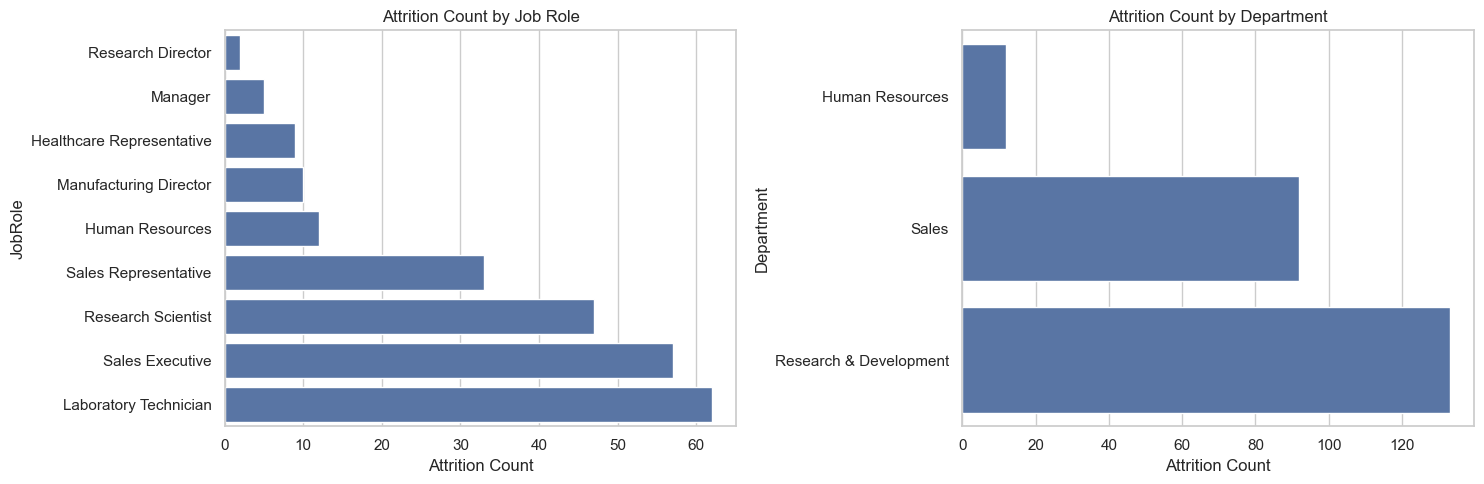

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

role_plot = role_summary.sort_values("Attritions", ascending=True)
sns.barplot(
    x=role_plot["Attritions"],
    y=role_plot.index,
    ax=axes[0]
)
axes[0].set_title("Attrition Count by Job Role")
axes[0].set_xlabel("Attrition Count")

dept_plot = department_summary.sort_values("Attritions", ascending=True)
sns.barplot(
    x=dept_plot["Attritions"],
    y=dept_plot.index,
    ax=axes[1]
)
axes[1].set_title("Attrition Count by Department")
axes[1].set_xlabel("Attrition Count")

plt.tight_layout()
plt.show()


## 11. Correlation Analysis — Numeric Features

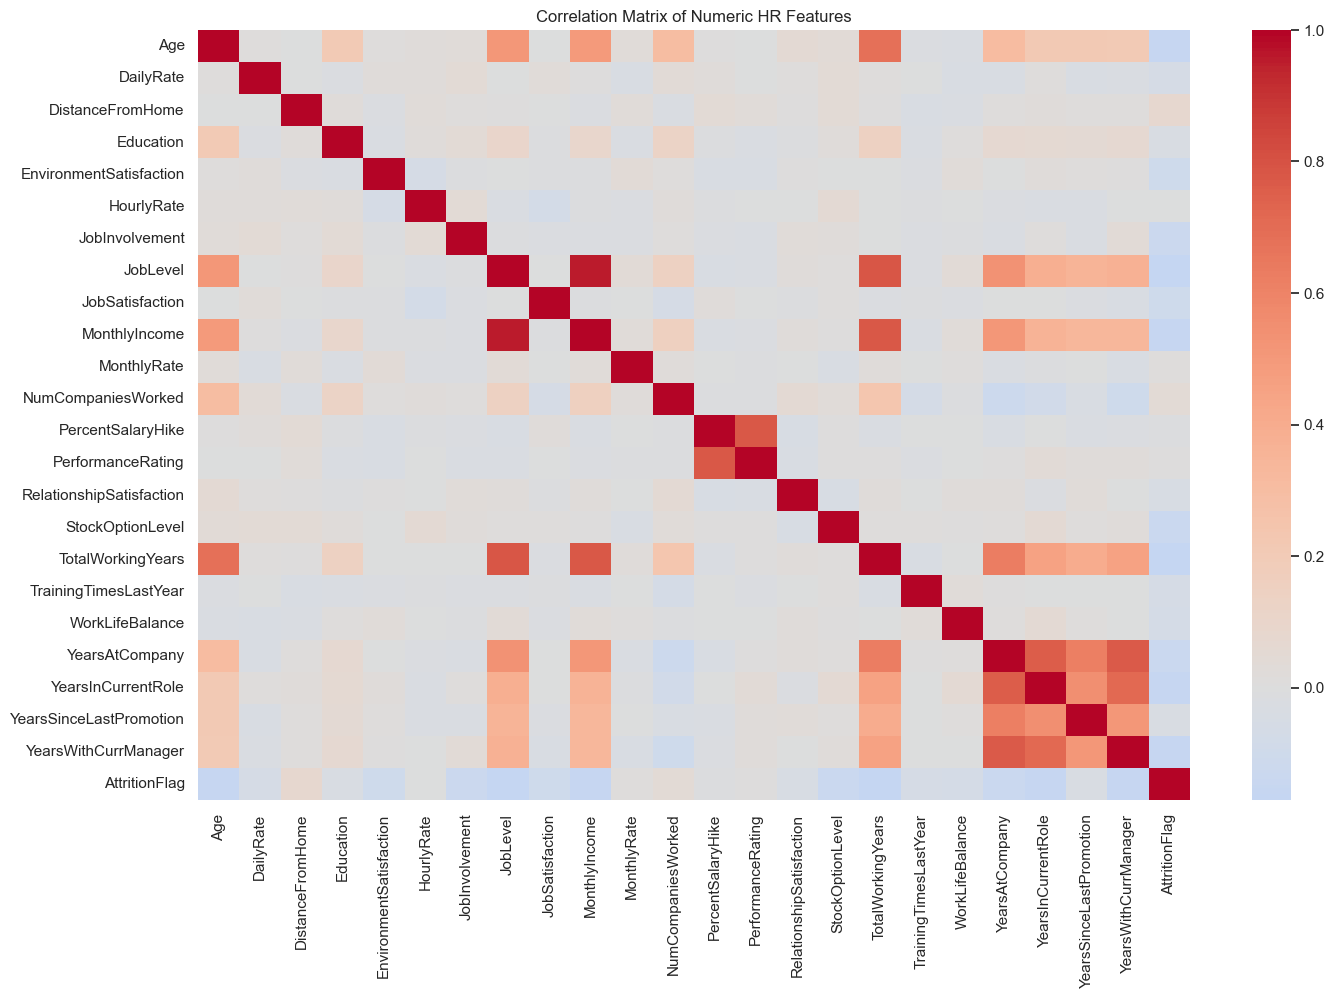

In [24]:
# Exclude the identifier from correlation analysis.
numeric_analysis_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_analysis_cols = [
    c for c in numeric_analysis_cols
    if c not in ["EmployeeNumber"]
]

corr = df[numeric_analysis_cols].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix of Numeric HR Features")
plt.show()


## 12. Correlation Specifically with Attrition

In [25]:
attrition_corr = (
    corr["AttritionFlag"]
    .drop("AttritionFlag")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(attrition_corr.to_frame("Correlation with Attrition"))


,Correlation with Attrition
TotalWorkingYears,-0.170847
JobLevel,-0.168926
YearsWithCurrManager,-0.161636
YearsInCurrentRole,-0.160302
MonthlyIncome,-0.159458
Age,-0.158775
StockOptionLevel,-0.136939
YearsAtCompany,-0.134106
JobInvolvement,-0.129678
EnvironmentSatisfaction,-0.104022


## 14. Final Analytical Takeaways

In [28]:
# Generate concise, data-backed summaries for interview preparation.

total_employees = len(df)
total_attrition = int(df["AttritionFlag"].sum())
overall_rate = round(total_attrition / total_employees * 100, 2)

print(f"1. Workforce analyzed: {total_employees:,} employees.")
print(f"2. Attrition cases: {total_attrition:,} ({overall_rate}%).")

print("\nTop job roles by attrition count:")
display(role_summary.head(4))

print("\nDepartments by attrition count:")
display(department_summary)

print("\nAverage values by attrition status:")
display(
    df.groupby("Attrition")[["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany"]]
      .mean()
      .round(2)
)


1. Workforce analyzed: 1,473 employees.
2. Attrition cases: 237 (16.09%).

Top job roles by attrition count:


,Employees,Attritions,AttritionRate_%
JobRole,,,
Laboratory Technician,260,62,23.85
Sales Executive,326,57,17.48
Research Scientist,292,47,16.10
Sales Representative,84,33,39.29



Departments by attrition count:


,Employees,Attritions,AttritionRate_%
Department,,,
Research & Development,963,133,13.81
Sales,447,92,20.58
Human Resources,63,12,19.05



Average values by attrition status:


,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany
Attrition,,,,
No,37.55,6828.72,11.86,7.36
Yes,33.61,4787.09,8.24,5.13
